# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [17]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# third parties imports
import numpy as np 
import pandas as pd
# -- add new imports here --
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
# local imports
from constants import Constant as C
from loaders import load_ratings
from loaders import load_items

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 - Content analytics
Explore and perform descriptive statistics on content data

In [18]:
# -- load the items and display the Dataframe

df_items = load_items()
display(df_items)

,title,genres
movieId,,
1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,Jumanji (1995),Adventure|Children|Fantasy
3,Grumpier Old Men (1995),Comedy|Romance
4,Waiting to Exhale (1995),Comedy|Drama|Romance
5,Father of the Bride Part II (1995),Comedy
...,...,...
161582,Hell or High Water (2016),Crime|Drama
161594,Kingsglaive: Final Fantasy XV (2016),Action|Adventure|Animation|Drama|Fantasy|Sci-Fi
161918,Sharknado 4: The 4th Awakens (2016),Action|Adventure|Horror|Sci-Fi


In [19]:
# -- display relevant informations that can be extracted from the dataset

# The number of movies
n_movies = len(df_items)
print(f"Number of movies: {n_movies}")

# Year range 
df_items['year'] = df_items[C.LABEL_COL].str.extract(r'\((\d{4})\)').astype(float)
min_year = df_items['year'].min()
max_year = df_items['year'].max()
print(f"Year range: {int(min_year)} - {int(max_year)}")

# List of unique movie genres
genres_list = df_items[C.GENRES_COL].str.split('|').explode().unique()
print(f"Movie genres: {list(genres_list)}")

Number of movies: 8737
Year range: 1902 - 2016
Movie genres: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy', 'Romance', 'Drama', 'Action', 'Crime', 'Thriller', 'Horror', 'Mystery', 'Sci-Fi', 'Documentary', 'IMAX', 'War', 'Musical', 'Western', 'Film-Noir', '(no genres listed)']


# 2 - Evidence analytics
Explore and perform descriptive statistics on evidence data

In [20]:
# -- load the items and display the Dataframe

df_ratings = load_ratings()
display(df_ratings)

,userId,movieId,rating,timestamp
0,277,6,5.0,836983211
1,277,7,5.0,851419421
2,277,10,3.0,836982963
3,277,16,5.0,836983252
4,277,18,3.0,836984035
...,...,...,...,...
381176,283184,5553,2.0,1042416423
381177,283184,5673,5.0,1042414496
381178,283184,5689,3.0,1042414792
381179,283184,5902,5.0,1042414483


In [26]:
# -- display relevant informations that can be extracted from the dataset

# (A) The total number of rating 
total_ratings = len(df_ratings[C.RATING_COL])
print(f"Total number of ratings: {total_ratings}")

# (B) The number of unique users
n_unique_users = df_ratings[C.USER_ID_COL].nunique() 
print(f"Number of unique users: {n_unique_users}")

# (C) The number of unique movies (in the ratings matrix)
n_unique_movies = df_ratings[C.ITEM_ID_COL].nunique() 
print(f"Number of unique movies: {n_unique_movies}")

# (D) The number of ratings of the most rated movie(s) 
# (E) The number of ratings of the less rated movie(s)
ratings_per_movie = df_ratings.groupby(C.ITEM_ID_COL).size()
max_ratings = ratings_per_movie.max()
min_ratings = ratings_per_movie.min()
print(f"Number of ratings of the most rated movie: {max_ratings}")
print(f"Number of ratings of the least rated movie: {min_ratings}")

# (F) All the possible rating values, from smallest value to value highest
rating_values = sorted([float(v) for v in df_ratings[C.RATING_COL].unique()])
print(f"All possible rating values: {rating_values}")

# (G) The number of movies that were not rated at all
catalog_ids = set(df_items.index) 
rated_ids = set(df_ratings[C.ITEM_ID_COL])
not_rated_count = len(catalog_ids - rated_ids)
print(f"Number of movies that were not rated at all: {not_rated_count}")

Total number of ratings: 381181
Number of unique users: 1000
Number of unique movies: 8737
Number of ratings of the most rated movie: 837
Number of ratings of the least rated movie: 1
All possible rating values: [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
Number of movies that were not rated at all: 0


# 3 - Long-tail property

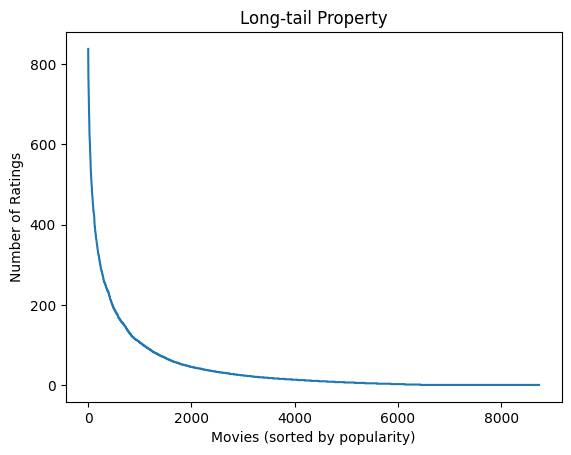

In [22]:
# (1) Count the number of ratings per movie
movie_counts = df_ratings[C.ITEM_ID_COL].value_counts()

# (2) Sort the counts from highest to lowest
sorted_counts = movie_counts.sort_values(ascending=False).values

# (3) Simple plot
plt.plot(sorted_counts)
plt.title("Long-tail Property")
plt.xlabel("Movies (sorted by popularity)")
plt.ylabel("Number of Ratings")
plt.show()

# 4 - Ratings matrix sparsity

Matrix sparsity: 95.64%


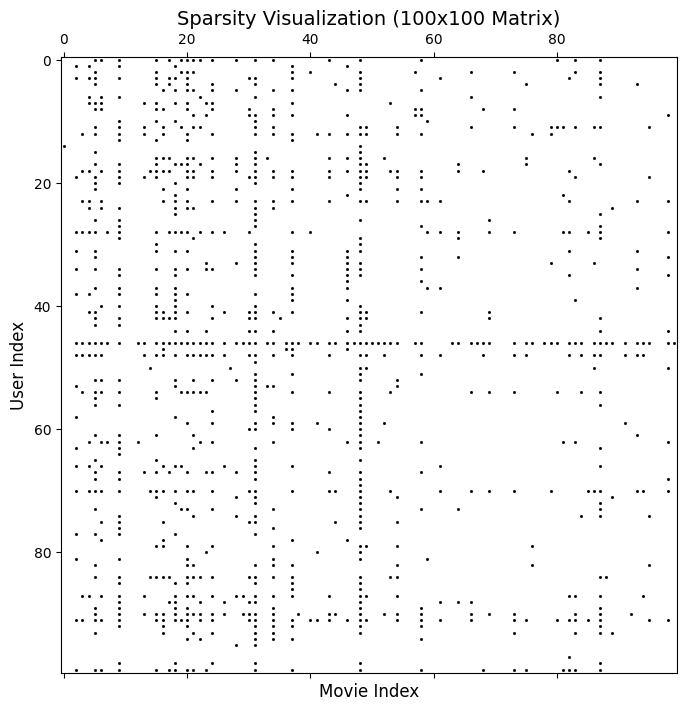

In [23]:
# STEP 1 : Create the Sparse Matrix
def create_X(df):
    M = df[C.USER_ID_COL].nunique()
    N = df[C.ITEM_ID_COL].nunique()

    user_mapper = dict(zip(np.unique(df[C.USER_ID_COL]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df[C.ITEM_ID_COL]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df[C.USER_ID_COL])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df[C.ITEM_ID_COL])))

    user_index = [user_mapper[i] for i in df[C.USER_ID_COL]]
    item_index = [movie_mapper[i] for i in df[C.ITEM_ID_COL]]

    X = csr_matrix((df[C.RATING_COL], (user_index, item_index)), shape=(M, N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

# Generate the matrix using the ratings dataframe
X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df_ratings)


# STEP 2 : Compute Sparsity Metric
n_total = X.shape[0] * X.shape[1]  # Total cells (Users * Movies)
n_ratings = X.nnz                  # Number of specified ratings
sparsity_metric = 1 - (n_ratings / n_total)

print(f"Matrix sparsity: {round(sparsity_metric * 100, 2)}%")


# STEP 3 : Visual Observation with .spy()
# Create the plot
plt.figure(figsize=(8, 8))

# We slice the first 100 rows and 100 columns of X
plt.spy(X[:100, :100], markersize=1, color='black')

plt.title("Sparsity Visualization (100x100 Matrix)", fontsize=14)
plt.xlabel("Movie Index", fontsize=12)
plt.ylabel("User Index", fontsize=12)

plt.show()


# 5 - Visual Comparison of Models

Comparison of all latent factor models across all evaluation metrics.
RMSE/MAE are excluded for iALS and BPR (not meaningful for these models).

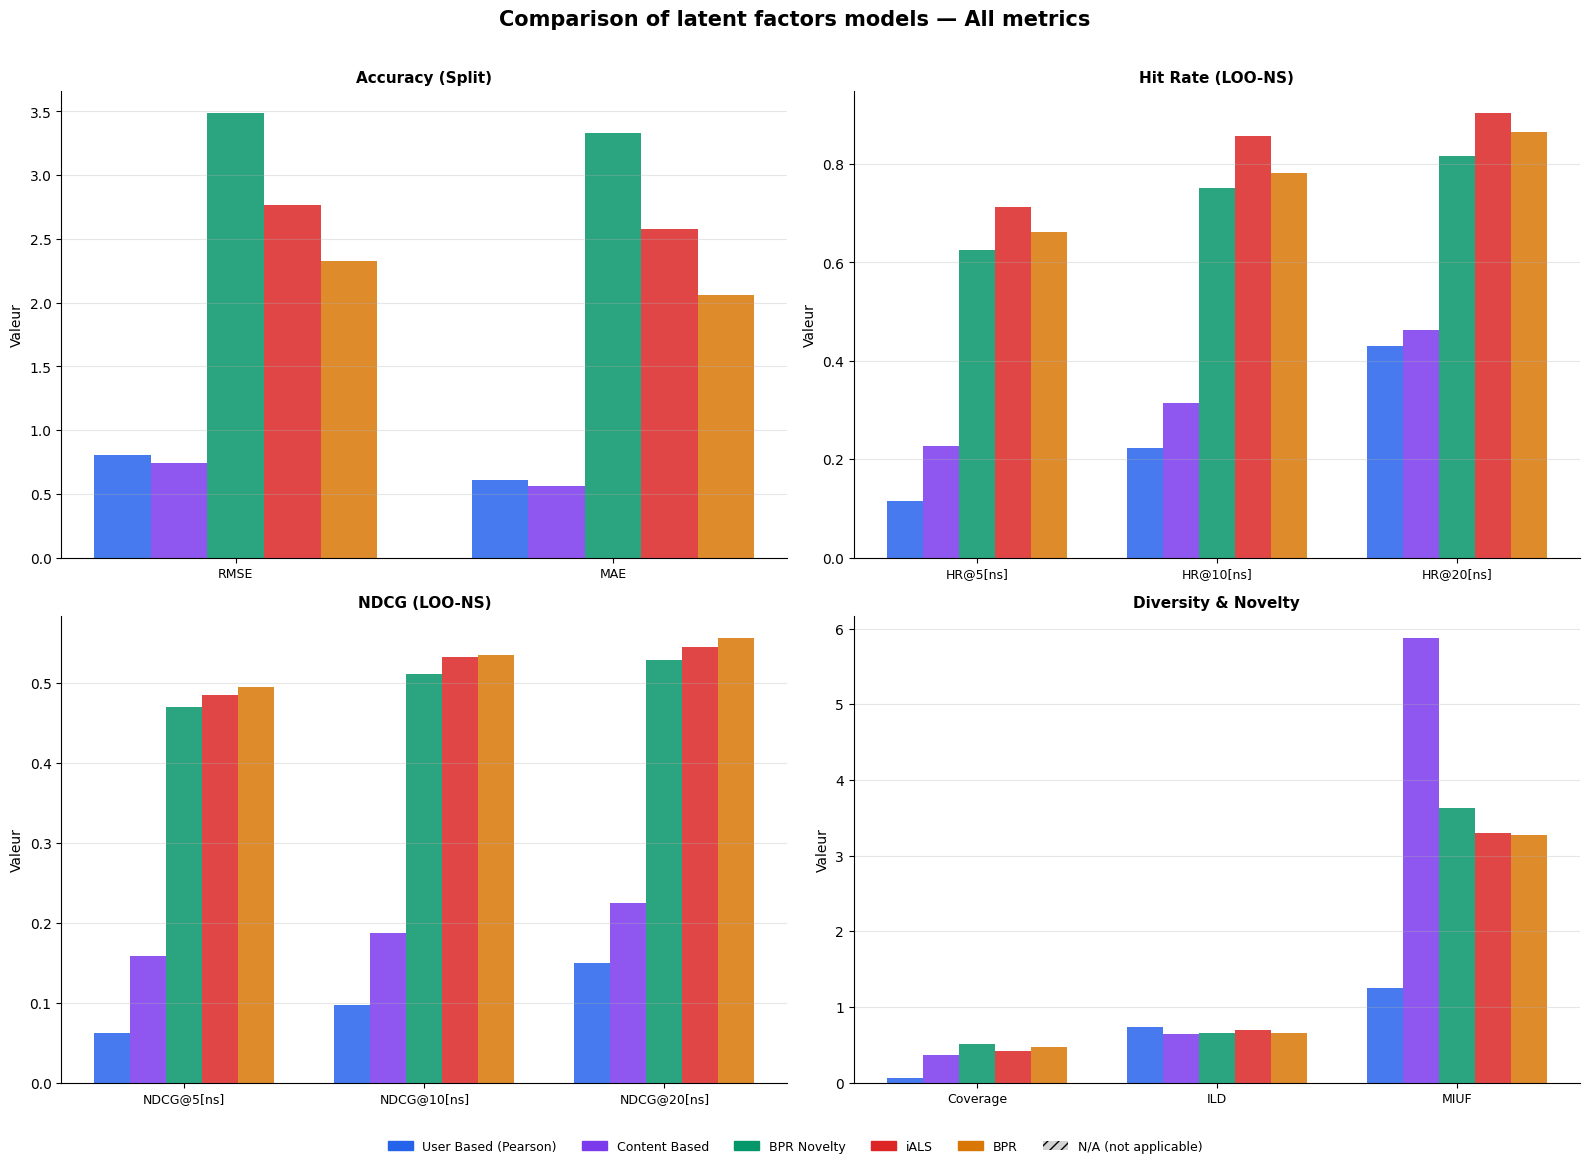

Sources: latest evaluator's results — LOO + 99 negatives protocol (He et al. 2017, WWW)


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Consolidated data
data = {
    'Modele':      ['User Based (Pearson)', 'Content Based', 'BPR Novelty', 'iALS', 'BPR'],
    'RMSE':        [0.805, 0.744, 3.489, 2.768, 2.328],
    'MAE':         [0.611, 0.561, 3.334, 2.577, 2.057],
    'HR@5[ns]':    [0.115, 0.226, 0.625, 0.712, 0.661],
    'HR@10[ns]':   [0.222, 0.315, 0.751, 0.857, 0.782],
    'HR@20[ns]':   [0.430, 0.462, 0.817, 0.904, 0.866],
    'NDCG@5[ns]':  [0.062, 0.158, 0.469, 0.485, 0.495],
    'NDCG@10[ns]': [0.097, 0.187, 0.511, 0.532, 0.535],
    'NDCG@20[ns]': [0.149, 0.224, 0.528, 0.544, 0.556],
    'Coverage':    [0.061, 0.359, 0.512, 0.422, 0.475],
    'MIUF':        [1.252, 5.878, 3.627, 3.302, 3.275],
    'ILD':         [0.728, 0.643, 0.650, 0.691, 0.655],
}
df = pd.DataFrame(data).set_index('Modele')

groups = {
    'Accuracy (Split)':     ['RMSE', 'MAE'],
    'Hit Rate (LOO-NS)':     ['HR@5[ns]', 'HR@10[ns]', 'HR@20[ns]'],
    'NDCG (LOO-NS)':         ['NDCG@5[ns]', 'NDCG@10[ns]', 'NDCG@20[ns]'],
    'Diversity & Novelty': ['Coverage', 'ILD', 'MIUF'],
}

colors = ['#2563EB', '#7C3AED', '#059669', '#DC2626', '#D97706']
models = df.index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Comparison of latent factors models — All metrics',
             fontsize=15, fontweight='bold', y=1.01)

for ax, (group_name, metrics) in zip(axes.flat, groups.items()):
    x     = np.arange(len(metrics))
    n     = len(models)
    width = 0.15
    offset = np.linspace(-(n-1)/2, (n-1)/2, n) * width

    for j, (model, color) in enumerate(zip(models, colors)):
        vals = [df.loc[model, m] if pd.notna(df.loc[model, m]) else 0 for m in metrics]
        bars = ax.bar(x + offset[j], vals, width, label=model, color=color, alpha=0.85)
        for k, (bar, v) in enumerate(zip(bars, vals)):
            if pd.isna(df.loc[model, metrics[k]]):
                bar.set_hatch('///')
                bar.set_facecolor('lightgray')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_title(group_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valeur')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

handles = [mpatches.Patch(color=c, label=m) for c, m in zip(colors, models)]
na_patch = mpatches.Patch(facecolor='lightgray', hatch='///', label='N/A (not applicable)')
fig.legend(handles=handles + [na_patch], loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.show()
print("Sources: latest evaluator's results — LOO + 99 negatives protocol (He et al. 2017, WWW)")


# 6 - Carousel Overlap (iALS vs BPR)

Measures the proportion of films in common between the two main carousels:
**Top Picks For You** (iALS) and **Discover Something New** (BPR).

A low overlap validates the usefulness of having two distinct carousels.

In [29]:
import itertools, random
import numpy as np
import pandas as pd
from surprise import KNNBaseline
from models import ContentBased, ModeliALS, ModelBPR, get_top_n, get_top_n_reranked

N        = 40     
N_USERS  = 100     # user sample size (reduced to 100/80 for faster execution)
SEED     = 0

sp_ratings = load_ratings(surprise_format=True)
trainset   = sp_ratings.build_full_trainset()

# Per item popularity (for user-based reranking) — can be computed once for all models
item_freq = {trainset.to_raw_iid(i): len(trainset.ir[i]) for i in range(trainset.n_items)}

# ── Anti-testset built for sample only ──────────
random.seed(SEED)
sample_users = random.sample(range(trainset.n_users), k=min(N_USERS, trainset.n_users))
fill = trainset.global_mean
anti = [
    (trainset.to_raw_uid(u), trainset.to_raw_iid(i), fill)
    for u in sample_users
    for i in range(trainset.n_items)
    if i not in {iid for iid, _ in trainset.ur[u]}
]
print(f'Anti-testset reduced : {len(anti):,} pairs ({len(sample_users)} users)')

# ── Training the models (params = configs.py) ────────────────────────────
#print('Training content-based...')
#content_model = ContentBased(features_method="all_content_tmdb_tags2000", regressor_method="ridge_cv")
#content_model.fit(trainset)
#content_top_n = get_top_n(content_model.test(anti), n=N)

#print('Training user-based...')
#ub_model = KNNBaseline(k=40, min_k=2,
                        #sim_options={'name': 'pearson_baseline', 'user_based': True, 'min_support': 3})
#ub_model.fit(trainset)
#ub_top_n = get_top_n_reranked(ub_model.test(anti), item_freq, alpha=0.5, n=N)  # seul reranké

print('Training iALS...')
ials_model = ModeliALS(factors=50, iterations=20, regularization=0.01, alpha=40)
ials_model.fit(trainset)
ials_top_n = get_top_n(ials_model.test(anti), n=N)

print('Training BPR...')
bpr_model = ModelBPR(factors=64, learning_rate=0.01, regularization=0.01, iterations=100)
bpr_model.fit(trainset)
bpr_top_n = get_top_n(bpr_model.test(anti), n=N)

# ── Average overlap for each pair of models ─────────────────────────────────
top_ns = {'iALS': ials_top_n, 'BPR': bpr_top_n} # Add 'content' and 'user_based' if you want to include them in the comparison.

rows = []
for (name_a, ta), (name_b, tb) in itertools.combinations(top_ns.items(), 2):
    common = set(ta) & set(tb)
    ov = np.array([
        len({i for i, _ in ta[u]} & {i for i, _ in tb[u]}) / N * 100
        for u in common
    ])
    if ov.size == 0:
        continue
    rows.append({
        'Carrousel A': name_a, 'Carrousel B': name_b, 'Users': len(ov),
        'Average Overlap %': round(float(ov.mean()), 1),
        'Median %': round(float(np.median(ov)), 1),
        'Min %': round(float(ov.min()), 1), 'Max %': round(float(ov.max()), 1),
    })

overlap_table = (pd.DataFrame(rows)
                .sort_values('Average Overlap %', ascending=False)
                .reset_index(drop=True))
overlap_table.style.bar(subset=['Average Overlap %', 'Median %', 'Min %', 'Max %'], color='#d65f5f')

Anti-testset réduit : 836,532 paires (100 users)
Training iALS...


  0%|          | 0/20 [00:00<?, ?it/s]

Training BPR...


  0%|          | 0/100 [00:00<?, ?it/s]

/Users/arthurottevaere/Recommender_System_Assignments/venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4438: RuntimeWarning: invalid value encountered in scalar divide
  end = (x - left) / (right - left)


,Carrousel A,Carrousel B,Users,Overlap moyen %,Médiane %,Min %,Max %
0,iALS,BPR,100,21.600000,20.000000,0.000000,60.000000


# 7 - User Activity Distribution

Histogram of the number of ratings per user.
Identifies the proportion of cold-start users (< 20 ratings) vs power users (>= 200 ratings).
Systematically present in RecSys papers to characterise the dataset.

**Reference:** He et al. (2017, WWW) · Kang & McAuley (2018, ICDM) — Dataset Statistics section

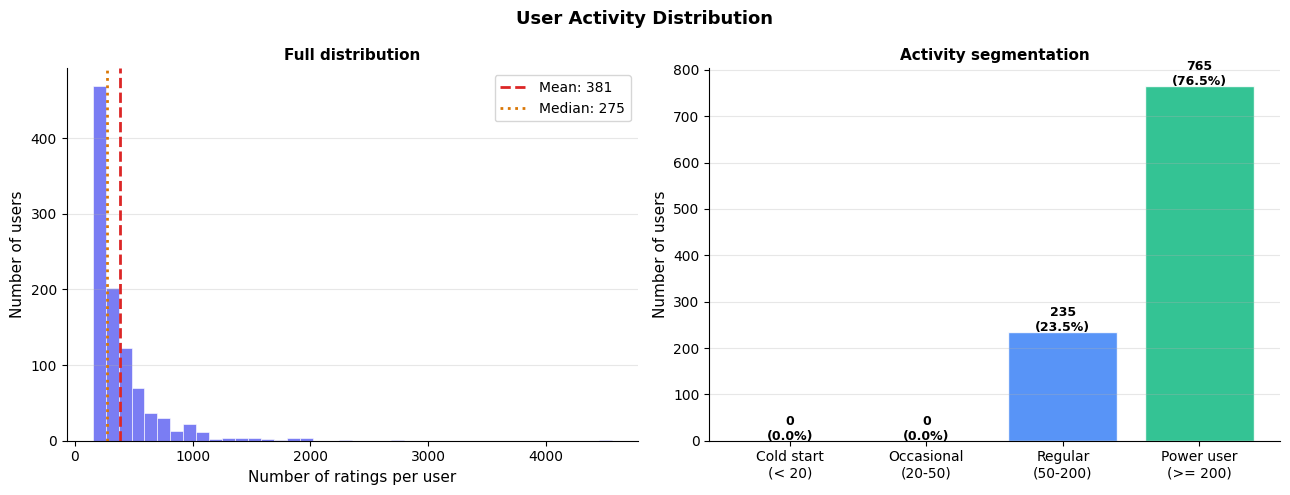

Total users          : 1000
Mean ratings/user    : 381.2
Median ratings/user  : 275


In [30]:
from loaders import load_ratings
user_activity = df_ratings.groupby(C.USER_ID_COL).size().reset_index(name='n_ratings')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("User Activity Distribution", fontsize=13, fontweight='bold')
ax1 = axes[0]
ax1.hist(user_activity['n_ratings'], bins=40, color='#6366F1', alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.axvline(user_activity['n_ratings'].mean(),   color='#DC2626', linestyle='--', linewidth=2, label=f"Mean: {user_activity['n_ratings'].mean():.0f}")
ax1.axvline(user_activity['n_ratings'].median(), color='#D97706', linestyle=':',  linewidth=2, label=f"Median: {user_activity['n_ratings'].median():.0f}")
ax1.set_xlabel('Number of ratings per user', fontsize=11)
ax1.set_ylabel("Number of users", fontsize=11)
ax1.set_title('Full distribution', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
ax2 = axes[1]
segments = {'Cold start\n(< 20)':   (user_activity['n_ratings'] < 20).sum(),
            'Occasional\n(20-50)':  ((user_activity['n_ratings'] >= 20) & (user_activity['n_ratings'] < 50)).sum(),
            'Regular\n(50-200)':    ((user_activity['n_ratings'] >= 50) & (user_activity['n_ratings'] < 200)).sum(),
            'Power user\n(>= 200)':  (user_activity['n_ratings'] >= 200).sum()}
colors_seg = ['#EF4444', '#F59E0B', '#3B82F6', '#10B981']
bars = ax2.bar(segments.keys(), segments.values(), color=colors_seg, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, segments.values()):
    pct = val / len(user_activity) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel("Number of users", fontsize=11)
ax2.set_title('Activity segmentation', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f"Total users          : {len(user_activity)}")
print(f"Mean ratings/user    : {user_activity['n_ratings'].mean():.1f}")
print(f"Median ratings/user  : {user_activity['n_ratings'].median():.0f}")


# 8. Distribution of movie ratings

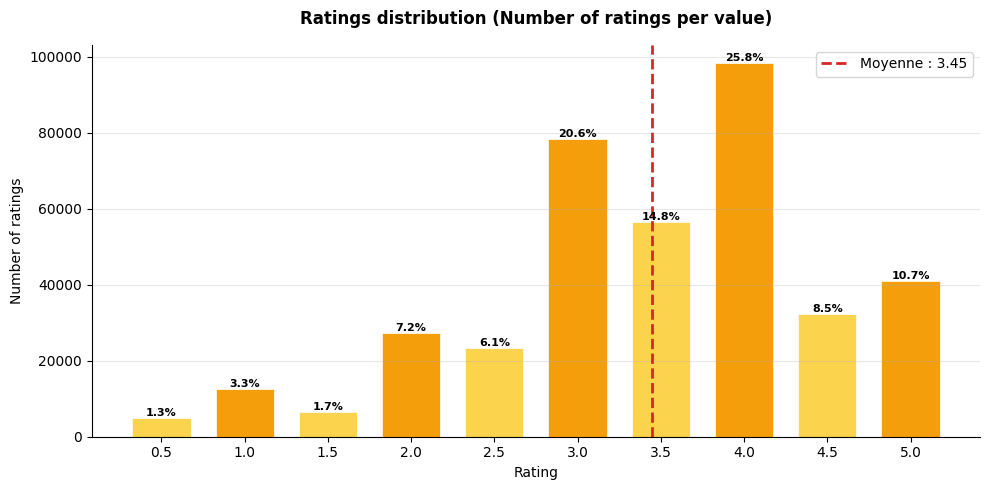

Total ratings      : 381181
Mean / median      : 3.45 / 3.5
Most given rating  : 4.0 (25.8%)
% ratings >= 4.0   : 45.0%  (positive bias)


In [42]:
# ============================================================
# Ratings distribution (from 0.5 – 5.0)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from loaders import load_ratings

df_ratings = load_ratings()
ratings = df_ratings[C.RATING_COL]

# Counting
counts = ratings.value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))

# (1) Barplot
colors = ['#F59E0B' if (v * 10) % 10 == 0 else '#FCD34D' for v in counts.index]
bars = ax.bar(counts.index, counts.values, width=0.35,
               color=colors, edgecolor='white', linewidth=0.5)

# List with average
ax.axvline(ratings.mean(), color='#DC2626', linestyle='--', linewidth=2,
           label=f"Moyenne : {ratings.mean():.2f}")

# Filling the chart
ax.set_title("Ratings distribution (Number of ratings per value)", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Rating", fontsize=10)
ax.set_ylabel("Number of ratings", fontsize=10)
ax.set_xticks(np.arange(0.5, 5.5, 0.5))
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# Cleaning the plot
ax.spines[['top', 'right']].set_visible(False)

# Adding percentage labels on top of bars
for x, v, p in zip(counts.index, counts.values, pct.values):
    ax.text(x, v, f"{p:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Total ratings      : {len(ratings)}")
print(f"Mean / median      : {ratings.mean():.2f} / {ratings.median():.1f}")
print(f"Most given rating  : {counts.idxmax()} ({pct.max():.1f}%)")
print(f"% ratings >= 4.0   : {(ratings >= 4.0).mean() * 100:.1f}%  (positive bias)")

# 9 - Rating Distribution by Genre

Average rating and volume of ratings per genre.
Reveals dataset biases that directly influence what models learn.

**Reference:** Pazzani & Billsus (2007) · Lops et al. (2011, RS Handbook)

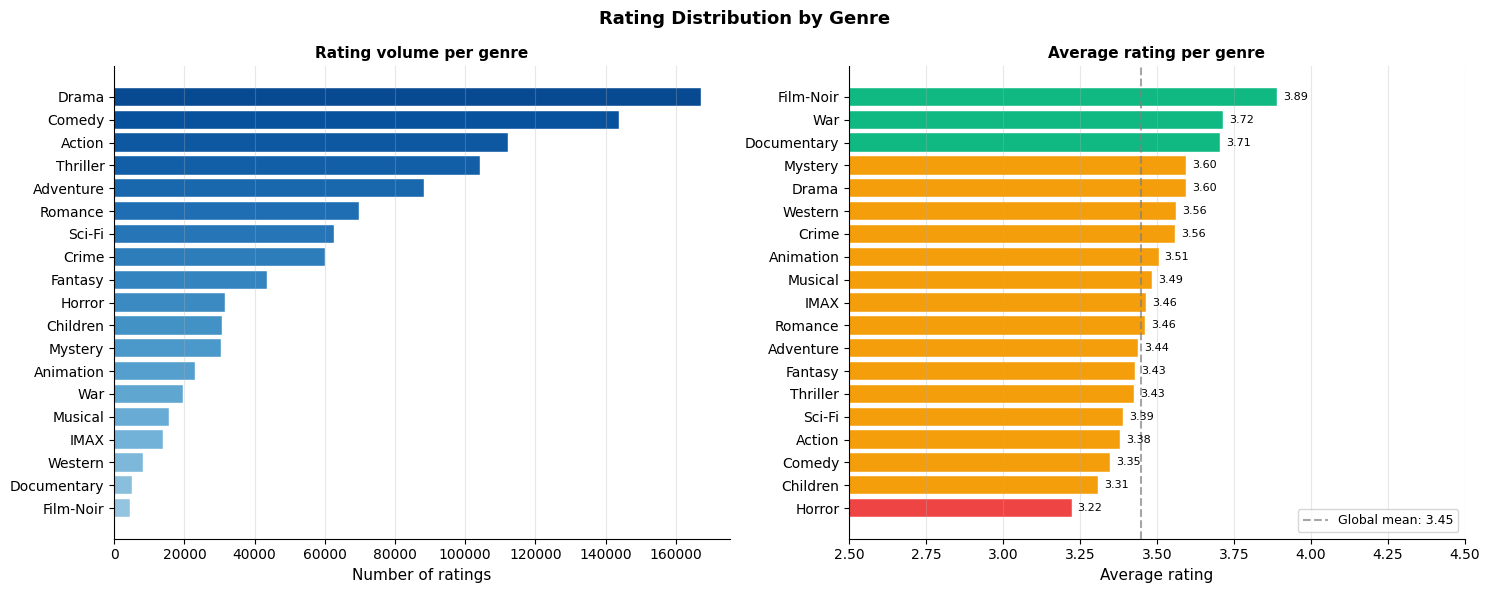

In [31]:
df_merged   = df_ratings.merge(df_items[['genres']], left_on=C.ITEM_ID_COL, right_index=True, how='left')
df_exploded = df_merged.assign(genre=df_merged['genres'].str.split('|')).explode('genre')
df_exploded = df_exploded[~df_exploded['genre'].isin(['(no genres listed)', ''])]
genre_stats = df_exploded.groupby('genre').agg(mean_rating=(C.RATING_COL, 'mean'), n_ratings=(C.RATING_COL, 'count')).sort_values('n_ratings', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Rating Distribution by Genre', fontsize=13, fontweight='bold')
ax1 = axes[0]
colors_g = plt.cm.Blues(np.linspace(0.4, 0.9, len(genre_stats)))[::-1]
ax1.barh(genre_stats['genre'], genre_stats['n_ratings'], color=colors_g, edgecolor='white', linewidth=0.3)
ax1.set_xlabel('Number of ratings', fontsize=11)
ax1.set_title('Rating volume per genre', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)
ax1.invert_yaxis()
ax2 = axes[1]
gs = genre_stats.sort_values('mean_rating', ascending=False)
cr = ['#10B981' if r >= 3.7 else '#F59E0B' if r >= 3.3 else '#EF4444' for r in gs['mean_rating']]
ax2.barh(gs['genre'], gs['mean_rating'], color=cr, edgecolor='white', linewidth=0.3)
ax2.axvline(df_ratings[C.RATING_COL].mean(), color='gray', linestyle='--', alpha=0.7, linewidth=1.5, label=f"Global mean: {df_ratings[C.RATING_COL].mean():.2f}")
for i, (val, bar) in enumerate(zip(gs['mean_rating'], ax2.patches)):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=8)
ax2.set_xlabel('Average rating', fontsize=11)
ax2.set_title('Average rating per genre', fontsize=11, fontweight='bold')
ax2.set_xlim(2.5, 4.5)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)
ax2.invert_yaxis()
plt.tight_layout()
plt.show()


# 10. Distribution of movies, ranked by year of release

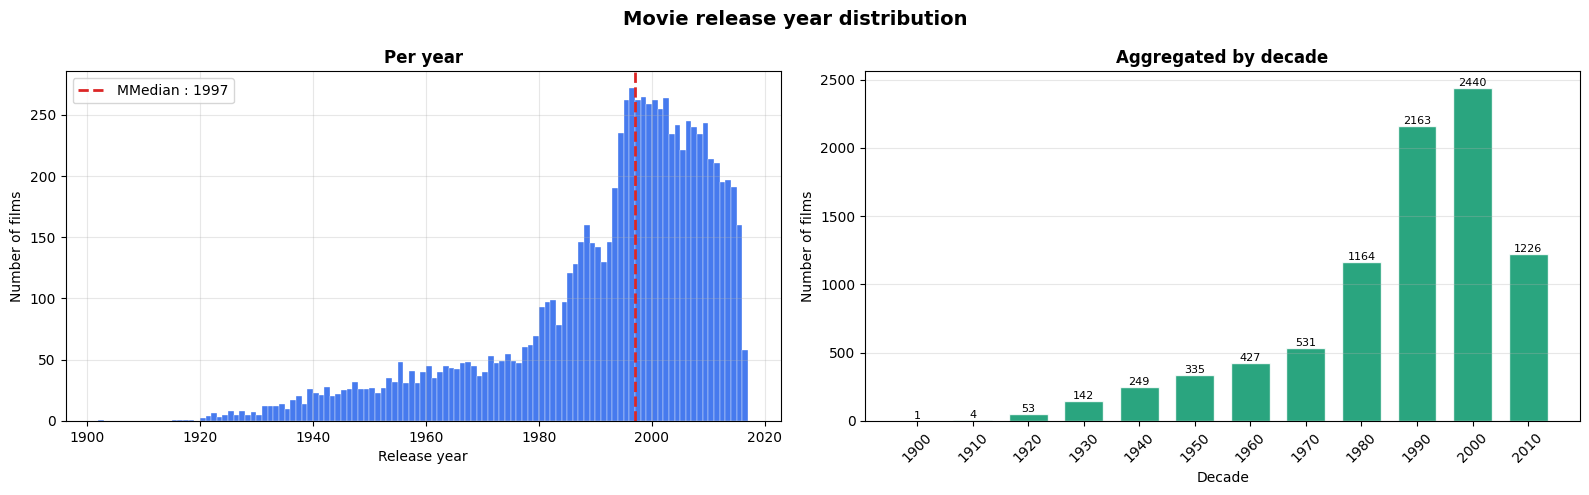

Dated movies        : 8735 / 8737
Range              : 1902 – 2016
Median / mean  : 1997 / 1992
Dominate decade : 2000s (2440 films)


In [43]:
# ============================================================
# Movie release year distribution
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_items = load_items()

# Extract the release years from the title (assuming format "Title (Year)")
years = df_items[C.LABEL_COL].str.extract(r'\((\d{4})\)')[0].astype(float).dropna()
years = years[(years >= 1900) & (years <= 2025)]  # garde-fou contre les valeurs aberrantes

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Movie release year distribution", fontsize=14, fontweight='bold')

# (1) Per year histogram
axes[0].hist(years, bins=range(int(years.min()), int(years.max()) + 2, 1),
            color='#2563EB', alpha=0.85, edgecolor='white', linewidth=0.3)
axes[0].axvline(years.median(), color='#DC2626', linestyle='--', linewidth=2,
                label=f"MMedian : {int(years.median())}")
axes[0].set_title("Per year", fontweight='bold')
axes[0].set_xlabel("Release year"); axes[0].set_ylabel("Number of films")
axes[0].legend(); axes[0].grid(alpha=0.3)

# (2) Aggregated by decade
decades = (years // 10 * 10).astype(int)
dec_counts = decades.value_counts().sort_index()
axes[1].bar(dec_counts.index.astype(str), dec_counts.values,
            width=0.7, color='#059669', alpha=0.85, edgecolor='white')
axes[1].set_title("Aggregated by decade", fontweight='bold')
axes[1].set_xlabel("Decade"); axes[1].set_ylabel("Number of films")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, axis='y')
for x, v in zip(range(len(dec_counts)), dec_counts.values):
    axes[1].text(x, v, str(v), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"Dated movies        : {len(years)} / {len(df_items)}")
print(f"Range              : {int(years.min())} – {int(years.max())}")
print(f"Median / mean  : {int(years.median())} / {years.mean():.0f}")
print(f"Dominate decade : {dec_counts.idxmax()}s ({dec_counts.max()} films)")


# 11 Co-occurence of genres in the movie catalog

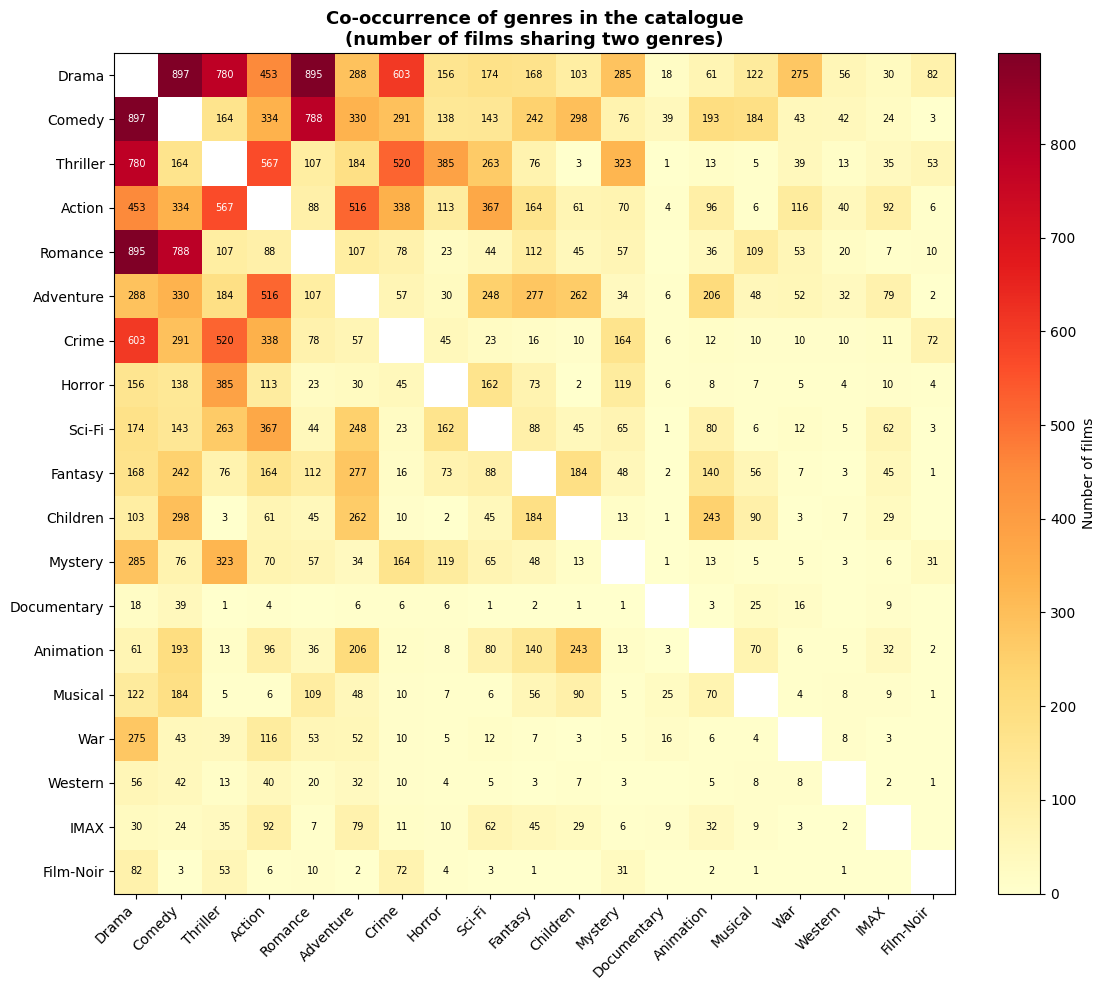

Top 10 of co-occuring genres :
  Drama        + Comedy       : 897 films
  Drama        + Romance      : 895 films
  Comedy       + Romance      : 788 films
  Drama        + Thriller     : 780 films
  Drama        + Crime        : 603 films
  Thriller     + Action       : 567 films
  Thriller     + Crime        : 520 films
  Action       + Adventure    : 516 films
  Drama        + Action       : 453 films
  Thriller     + Horror       : 385 films


In [40]:
 # ============================================================
# Co-occurrence of genres in the catalogue
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
from loaders import load_items
from constants import Constant as C

df_items = load_items()

# Genres list 
genre_lists = (
    df_items[C.GENRES_COL]
    .str.split('|')
    .apply(lambda gs: [g for g in gs if g not in ['(no genres listed)', '']])
)

# Genres ranked by frequency (for better visualization)
all_genres = [g for gs in genre_lists for g in gs]
genres_sorted = [g for g, _ in Counter(all_genres).most_common()]
idx = {g: i for i, g in enumerate(genres_sorted)}
n = len(genres_sorted)

# Co-occurence matrix
co = np.zeros((n, n), dtype=int)
for gs in genre_lists:
    for g in gs:
        co[idx[g], idx[g]] += 1
    for a, b in combinations(set(gs), 2):
        co[idx[a], idx[b]] += 1
        co[idx[b], idx[a]] += 1

co_df = pd.DataFrame(co, index=genres_sorted, columns=genres_sorted)

# --- Heatmap ---
co_off = co_df.copy().astype(float)
co_off = co_df.copy().astype(float)
# ensure writable underlying array (avoid read-only numpy view)
co_off = co_off.copy()
arr = co_off.to_numpy(copy=True)
np.fill_diagonal(arr, np.nan)
co_off.iloc[:, :] = arr
np.fill_diagonal(co_off.to_numpy(copy=True), np.nan)
co_off.iloc[:, :] = co_off.to_numpy(copy=True)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(co_off, cmap='YlOrRd')

ax.set_xticks(range(n)); ax.set_xticklabels(genres_sorted, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(genres_sorted)
ax.set_title("Co-occurrence of genres in the catalogue\n(number of films sharing two genres)",
            fontsize=13, fontweight='bold')

# Labelling the values, only non-diagonal and > 0
for i in range(n):
    for j in range(n):
        if i != j and co[i, j] > 0:
            ax.text(j, i, co[i, j], ha='center', va='center', fontsize=7,
                    color='black' if co[i, j] < np.nanmax(co_off.values) * 0.6 else 'white')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Number of films")
plt.tight_layout()
plt.show()

# Top 10 paires de genres les plus fréquentes
pairs = [(genres_sorted[i], genres_sorted[j], co[i, j])
        for i, j in combinations(range(n), 2) if co[i, j] > 0]
top_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:10]
print("Top 10 of co-occuring genres :")
for a, b, c in top_pairs:
    print(f"  {a:12s} + {b:12s} : {c} films")
